# Enhancing Guest Experience with Predictive Modeling and Demographic Clustering

---

### **Group Members**
- Harshini Reddy Penthala (1002193117)
- Jaswanth Surya Theja Jeldi (1002134474)
- Salman Saleem (1002198596)

---

### **Business Problem**
The hotel chain is experiencing a rising number of **special guest requests**, such as:
- Room preferences (bed type, view, floor)
- Amenities (extra towels, parking, baby cots)

Fulfilling these efficiently is critical for maintaining **guest satisfaction**, but the hotel struggles with:
- **Resource overload**
- **Delayed response times**
- **High operational costs**

Additionally, the hotel wants to **understand guest types** better to deliver more **personalized experiences**.

---

### **Project Objectives**
1. **Predict Special Requests**  
   Build a model that forecasts whether a guest will place a special request at the time of booking.

2. **Cluster Guests by Demographics**  
   Segment guests based on demographic features (e.g., country, market segment, customer type).

3. **Optimize Resource Allocation**  
   Use predictions to allocate staff and fulfill requests more effectively.

4. **Enhance Guest Experience**  
   Offer tailored services, improve satisfaction, and reduce staff burden.

---

### **Dataset**
- Source: [Kaggle - Hotel Booking Dataset](https://www.kaggle.com/datasets/mojtaba142/hotel-booking)
- Includes features like:
  - Booking details (lead time, room type, reservation status)
  - Guest details (country, market segment, customer type)
  - Special requests and preferences

---

### **Expected Outcomes**
- Accurate prediction of special requests at booking time
- Optimized staff planning and request fulfillment
- Clear segmentation of guest types for marketing and service strategies
- Increased guest satisfaction and loyalty through proactive, personalized service


In [1]:
import pandas as pd

df = pd.read_csv("hotel_booking.csv")

## 1. Data Loading and Initial Exploration

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [4]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,Transient,96.14,0,0,Check-Out,2017-09-06,Claudia Johnson,Claudia.J@yahoo.com,403-092-5582,************8647
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,Transient,225.43,0,2,Check-Out,2017-09-07,Wesley Aguilar,WAguilar@xfinity.com,238-763-0612,************4333
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,Transient,157.71,0,4,Check-Out,2017-09-07,Mary Morales,Mary_Morales@hotmail.com,395-518-4100,************1821
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,Transient,104.40,0,0,Check-Out,2017-09-07,Caroline Conley MD,MD_Caroline@comcast.net,531-528-1017,************7860
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,Transient,151.20,0,2,Check-Out,2017-09-07,Ariana Michael,Ariana_M@xfinity.com,422-804-6403,************4482


In [5]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
df.shape

(119390, 36)

In [9]:
#count of nulls 
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

## 2. Data Preperation

In [11]:
df.drop_duplicates(inplace=True)


In [12]:
cols_to_check = ['arrival_date_month', 'market_segment', 'customer_type', 'reserved_room_type',
                 'booking_changes', 'required_car_parking_spaces']
for col in cols_to_check:
    print(f"{col} unique values: {df[col].unique()}\n")


arrival_date_month unique values: ['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']

market_segment unique values: ['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary' 'Groups'
 'Undefined' 'Aviation']

customer_type unique values: ['Transient' 'Contract' 'Transient-Party' 'Group']

reserved_room_type unique values: ['C' 'A' 'D' 'E' 'G' 'F' 'H' 'L' 'P' 'B']

booking_changes unique values: [ 3  4  0  1  2  5 17  6  8  7 10 16  9 13 12 20 14 15 11 21 18]

required_car_parking_spaces unique values: [0 1 2 8 3]



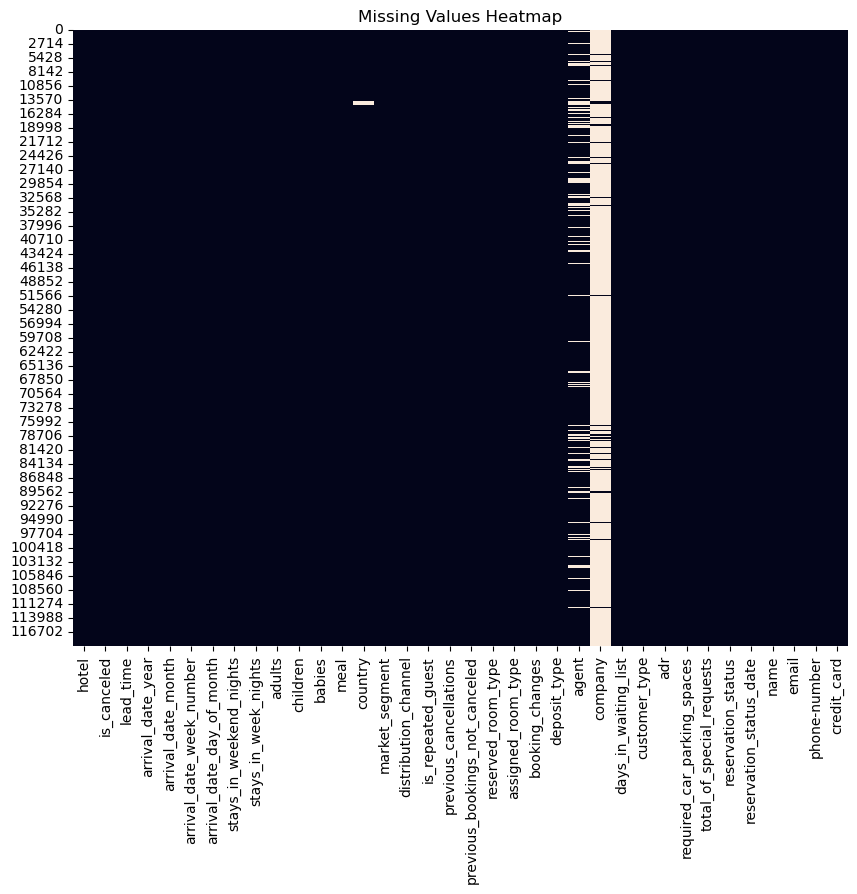

In [13]:
# Visualizing missing values
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(df.isnull(), cbar=False, cmap="rocket")
plt.title("Missing Values Heatmap")
plt.show()

In [14]:
# We will fill zero in case of null values for children
df['children'] = df['children'].fillna(0)
# We will fill zero in case of null values for agent
df['agent'] = df['agent'].fillna(0)
#Replace county with null values is most occuring country
df['country'] = df['country'].fillna(df['country'].mode()[0])
#dropping column company 
df = df.drop(columns=['company'])
#Adding a column to the dataset 
df['is_there_a_special_request'] = df['total_of_special_requests'].apply(lambda x: 1 if x > 0 else 0)

In [15]:
print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                             

## 3. Exploratory Data Analysis

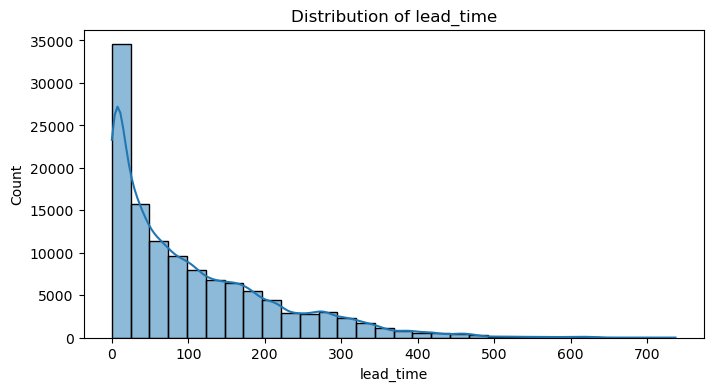

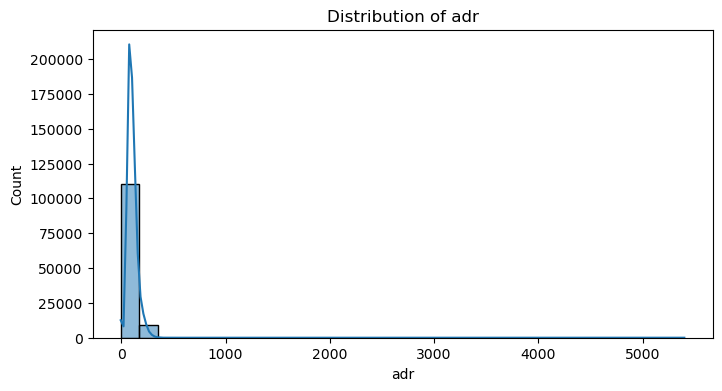

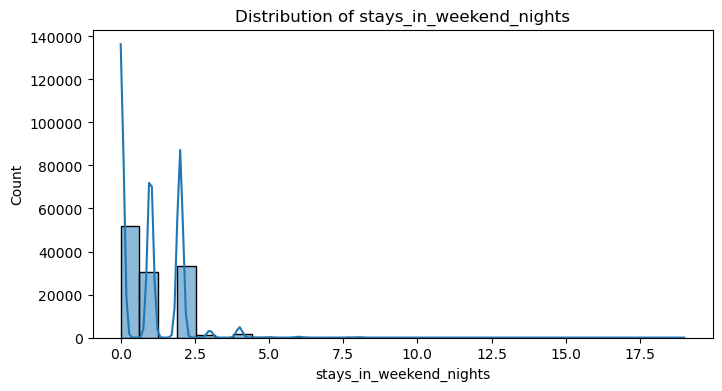

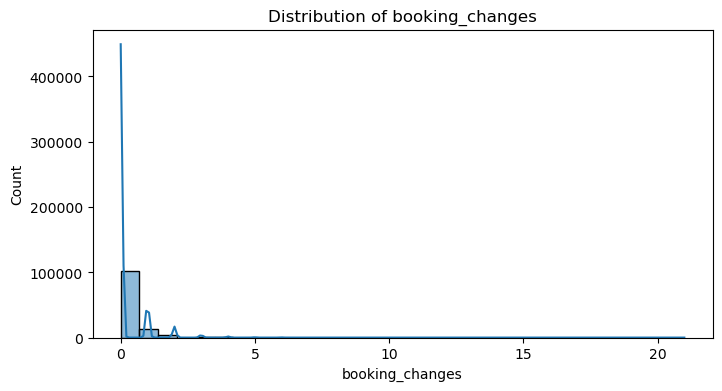

In [17]:
num_cols = ['lead_time', 'adr', 'stays_in_weekend_nights', 'booking_changes']

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()


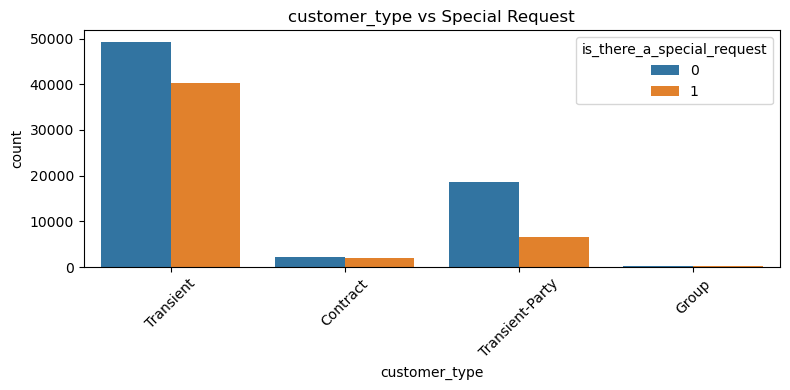

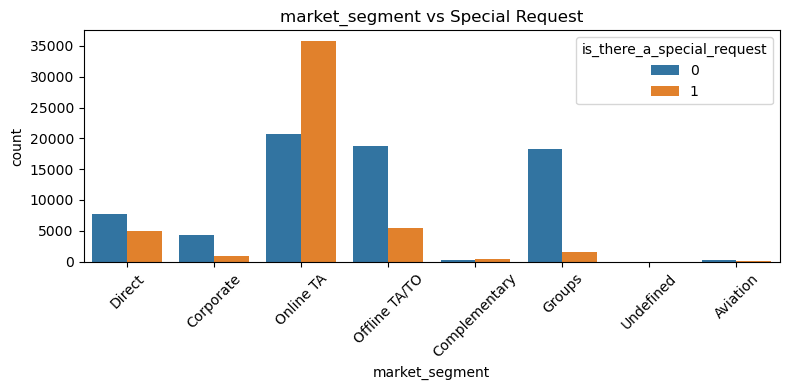

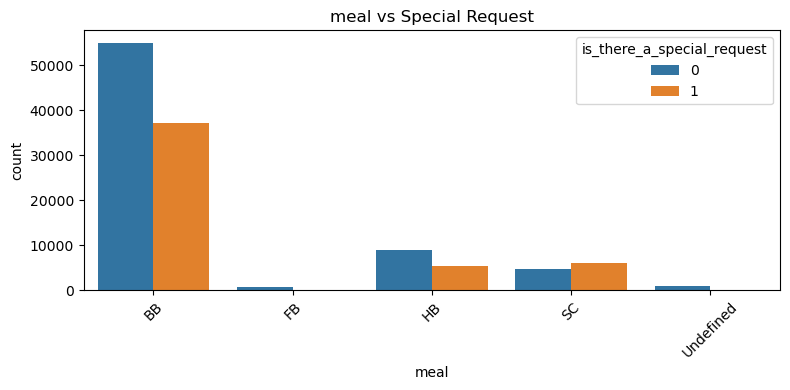

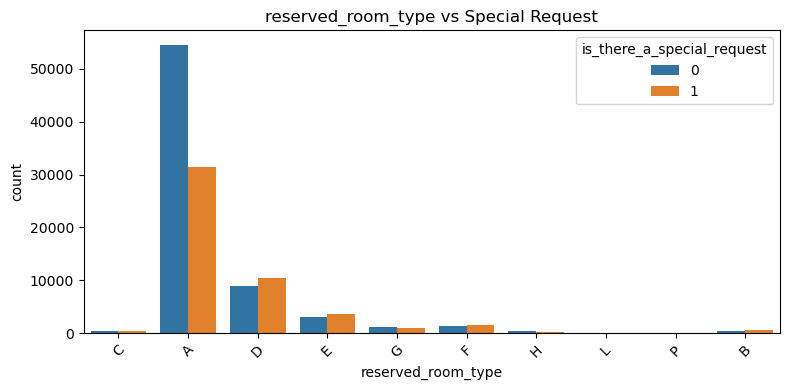

In [18]:
cat_cols = ['customer_type', 'market_segment', 'meal', 'reserved_room_type']

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='is_there_a_special_request')
    plt.title(f'{col} vs Special Request')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
label_enc = LabelEncoder()
label_cols = ['customer_type', 'arrival_date_month', 'meal', 'market_segment', 
              'distribution_channel', 'reserved_room_type', 'assigned_room_type', 
              'reservation_status', 'agent']

for col in label_cols:
    df[col] = label_enc.fit_transform(df[col])


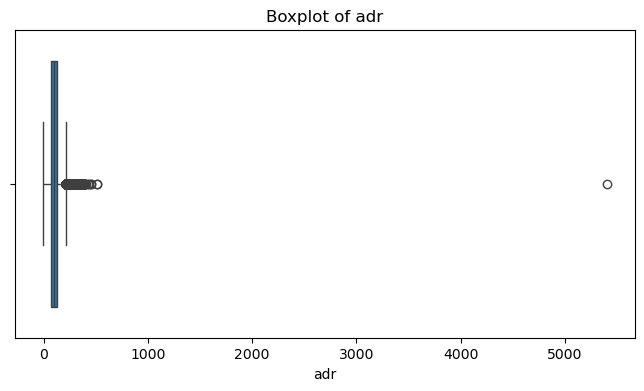

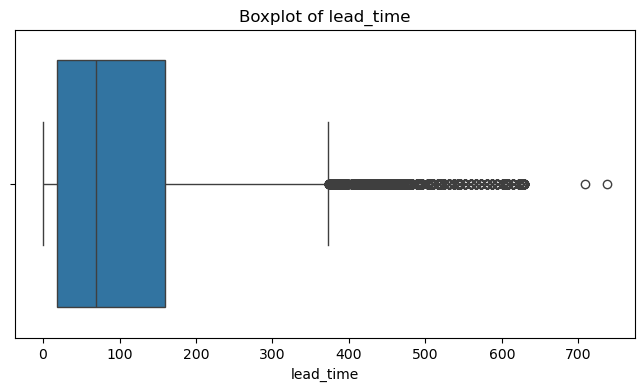

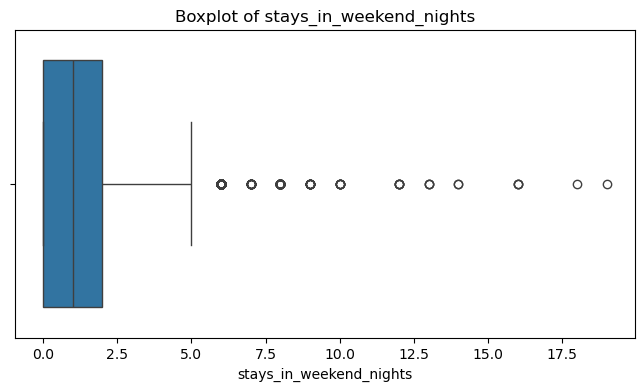

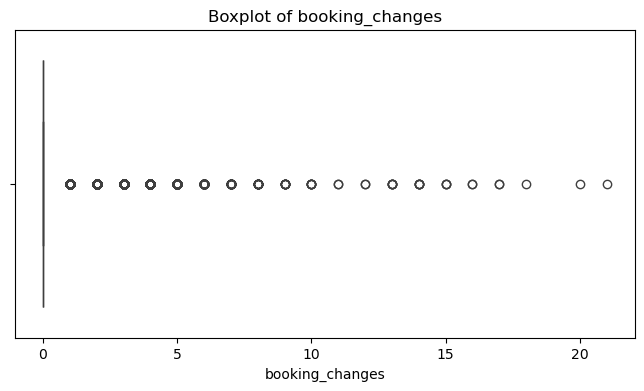

In [20]:
num_cols = ['adr', 'lead_time', 'stays_in_weekend_nights', 'booking_changes']

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()


In [21]:
classification_features = [
    "market_segment", "distribution_channel", "adr", "booking_changes", "agent", 
    "lead_time", "meal", "stays_in_weekend_nights", "arrival_date_month", 
    "arrival_date_week_number", "customer_type", "reserved_room_type", 
    "assigned_room_type", "reservation_status", "required_car_parking_spaces"
]
target = "is_there_a_special_request"

X = df[classification_features]
y = df[target]


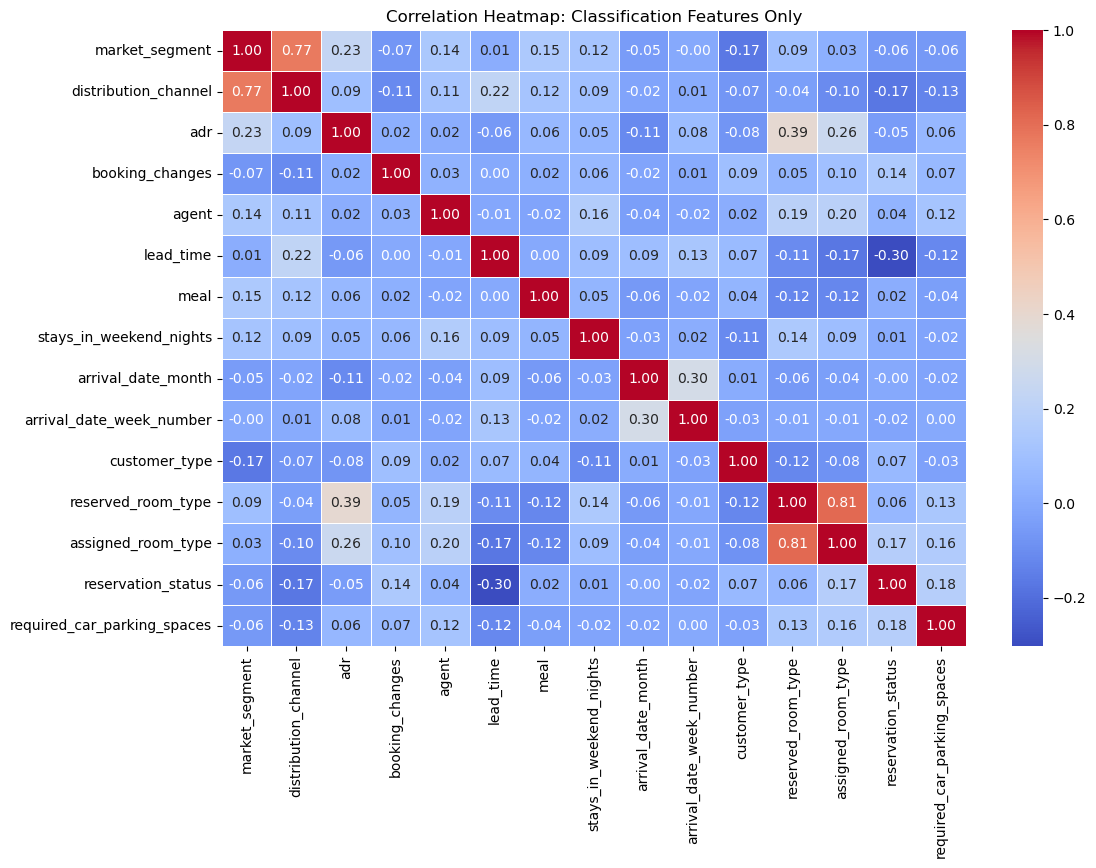

In [22]:
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap: Classification Features Only")
plt.show()


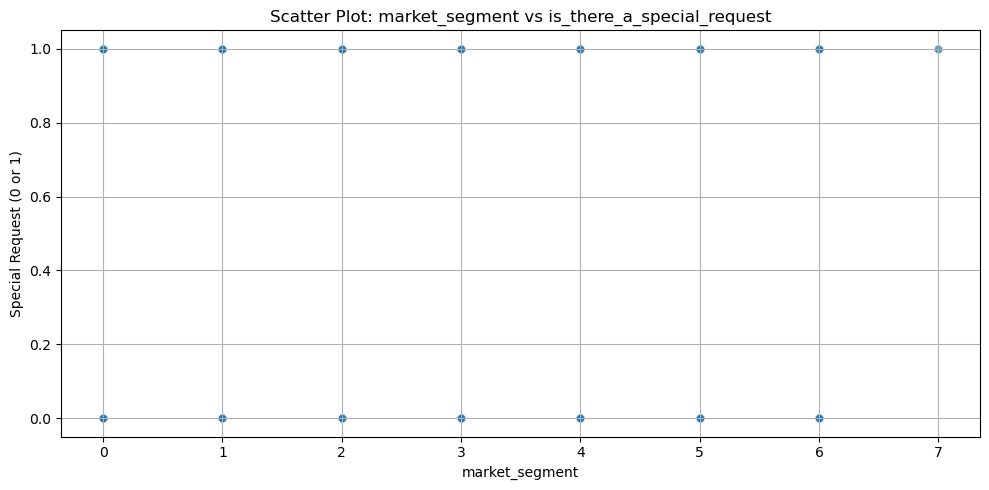

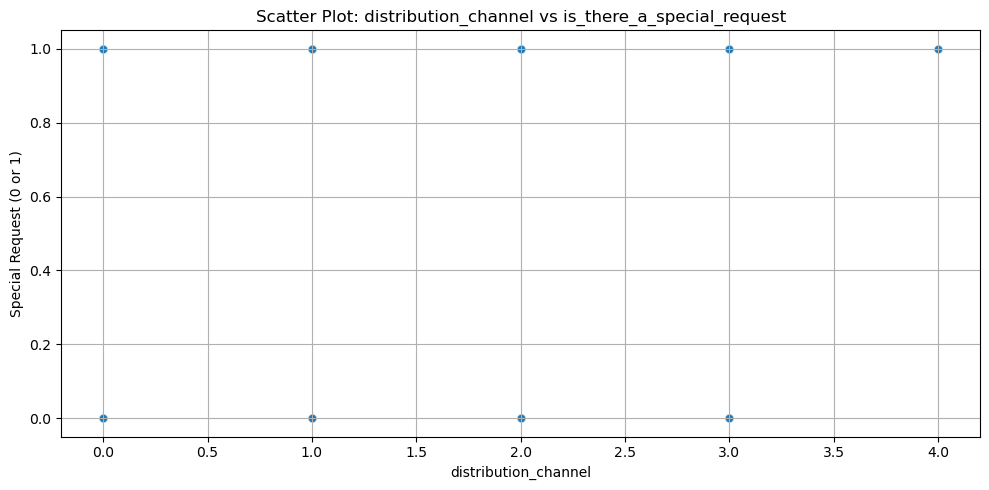

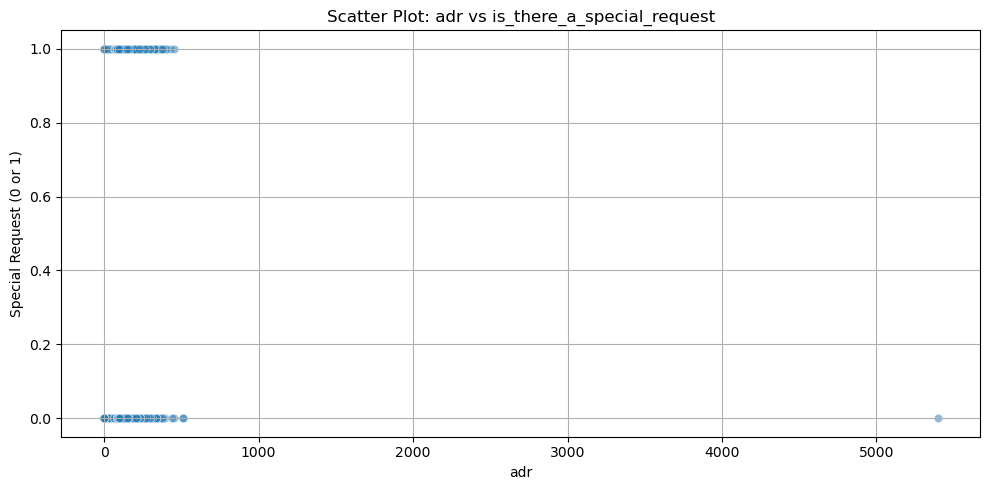

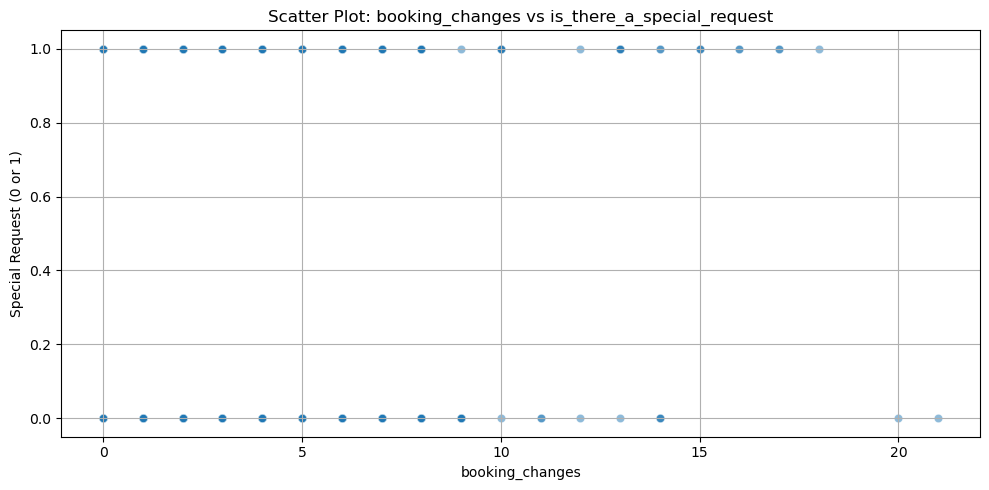

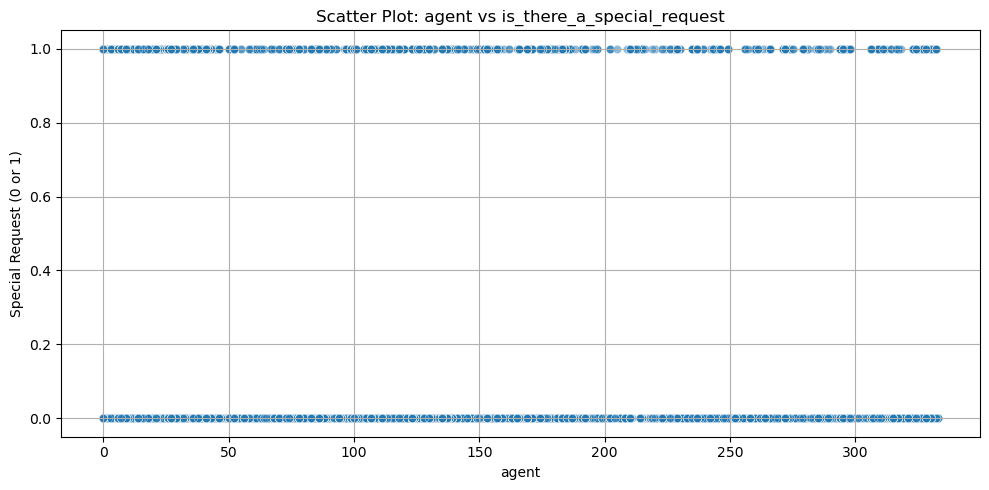

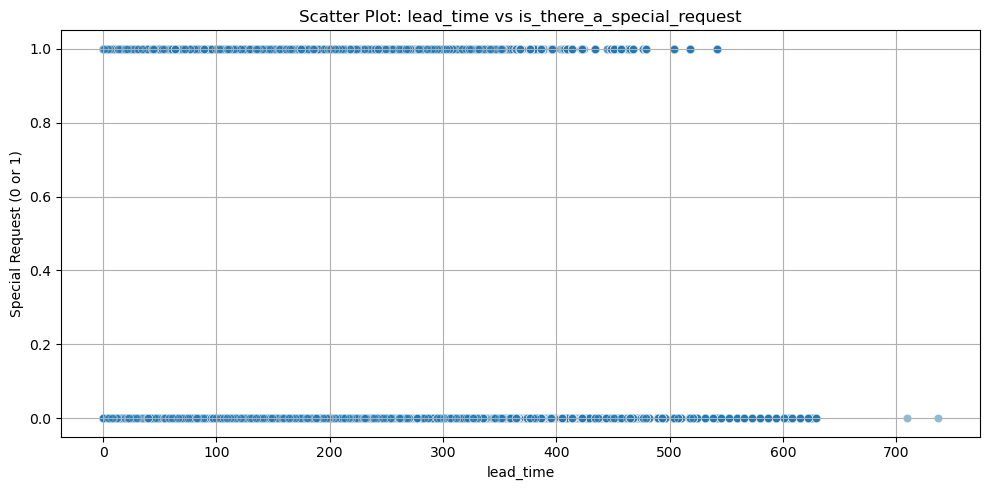

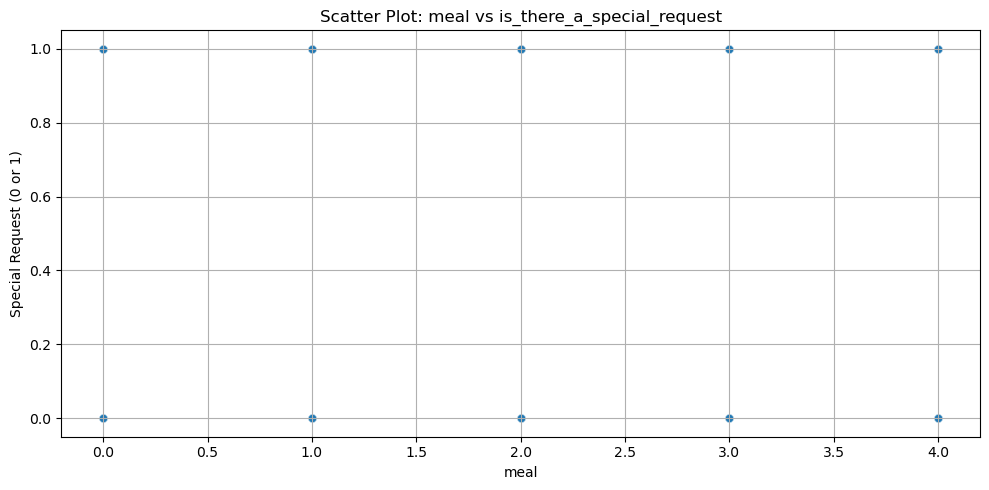

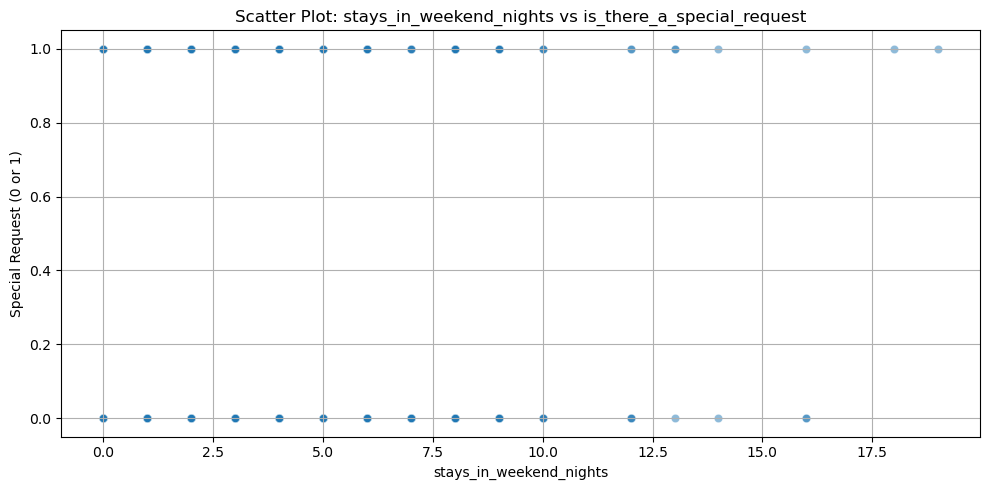

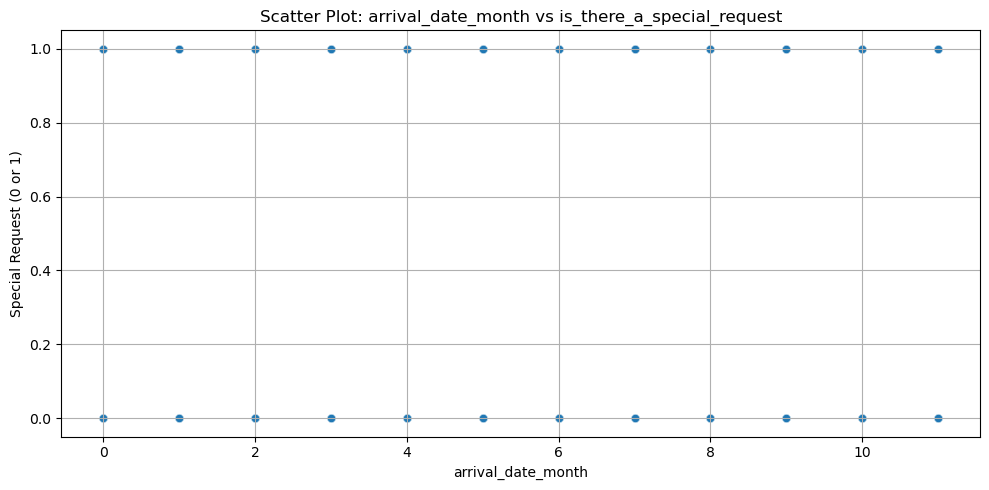

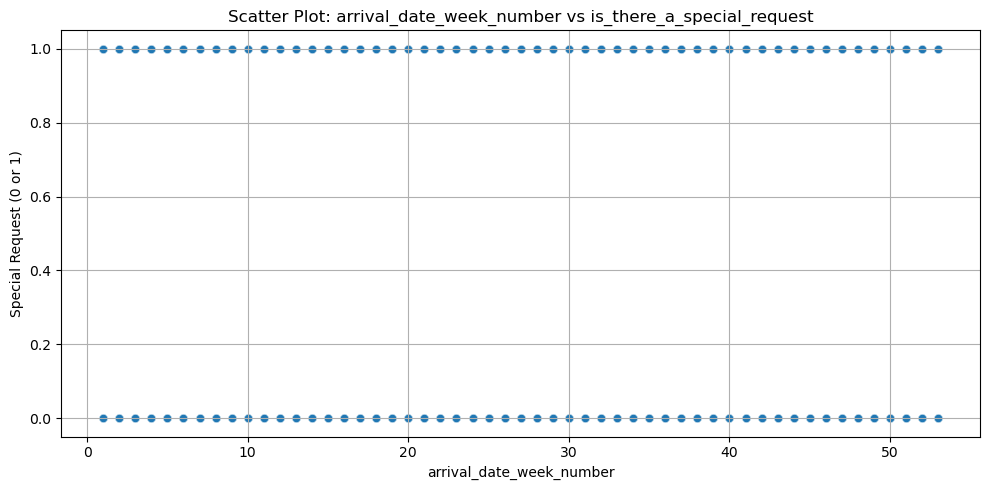

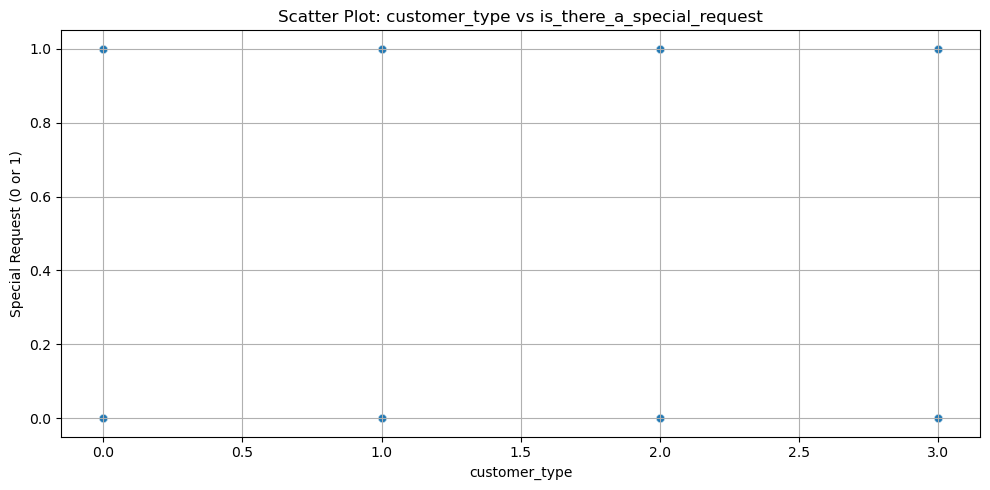

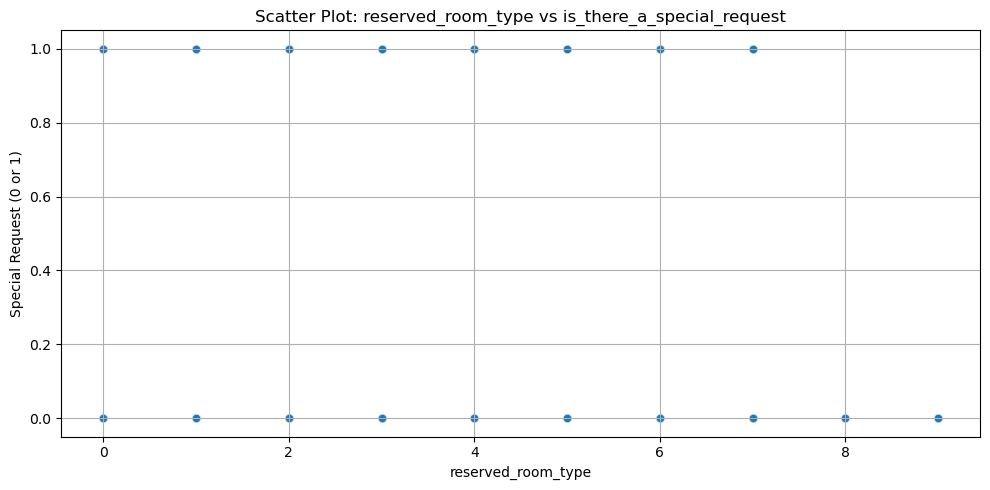

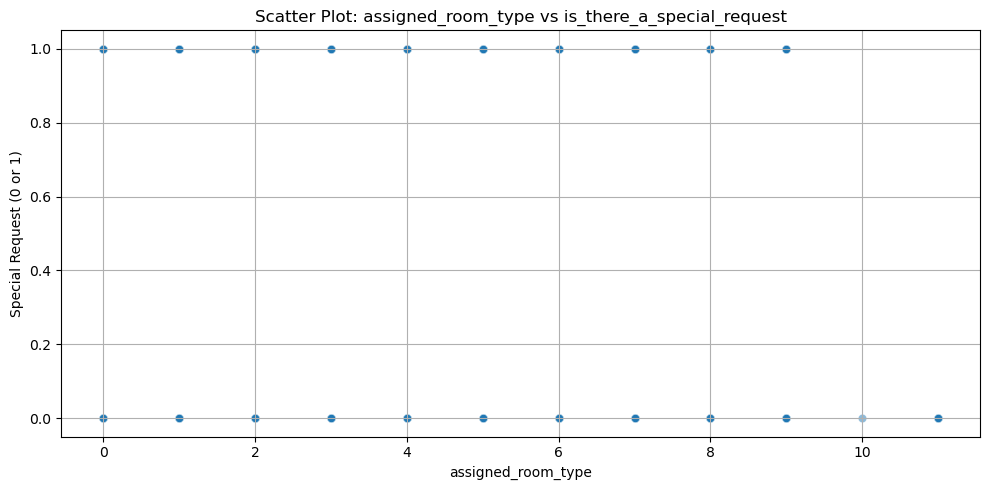

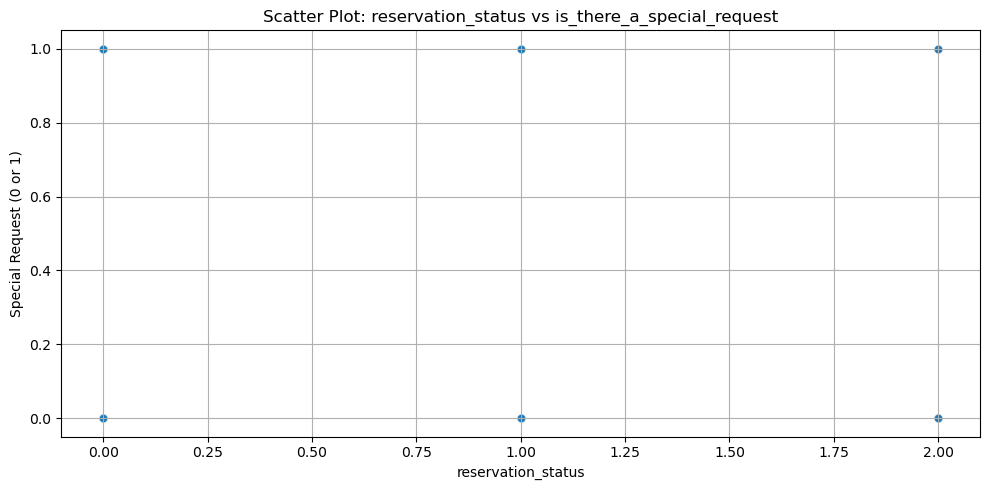

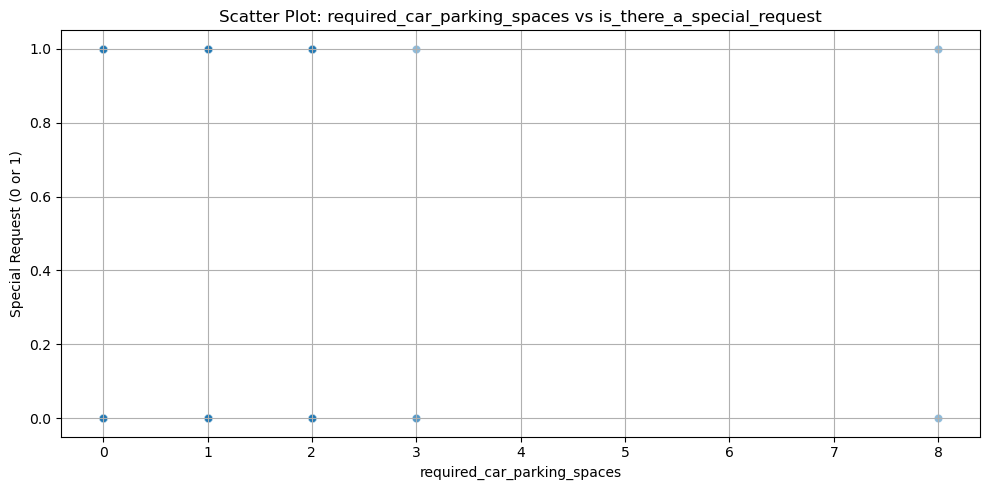

In [23]:
from pandas.api.types import is_numeric_dtype

for feature in classification_features:
    plt.figure(figsize=(10, 5))

    if is_numeric_dtype(df[feature]):
        sns.scatterplot(x=df[feature], y=df[target], alpha=0.5)
        plt.title(f"Scatter Plot: {feature} vs {target}")
        plt.ylabel("Special Request (0 or 1)")
        plt.grid(True)
    else:
        sns.countplot(data=df, x=feature, hue=target)
        plt.title(f"Count Plot: {feature} by {target}")
        plt.xticks(rotation=45)

    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()


## 4. Feature Importance Analysis

To identify the most influential features for predicting special requests, we applied three techniques:

- Mutual Information (Information Gain),Gain Ratio,Random Forest Feature Importance



 Mutual Information (Information Gain):
 agent                          0.139725
market_segment                 0.118424
adr                            0.092156
reservation_status             0.045900
lead_time                      0.029725
reserved_room_type             0.018323
customer_type                  0.015740
assigned_room_type             0.014604
meal                           0.013376
distribution_channel           0.013362
arrival_date_week_number       0.007420
arrival_date_month             0.006513
stays_in_weekend_nights        0.006124
required_car_parking_spaces    0.005649
booking_changes                0.004749
dtype: float64


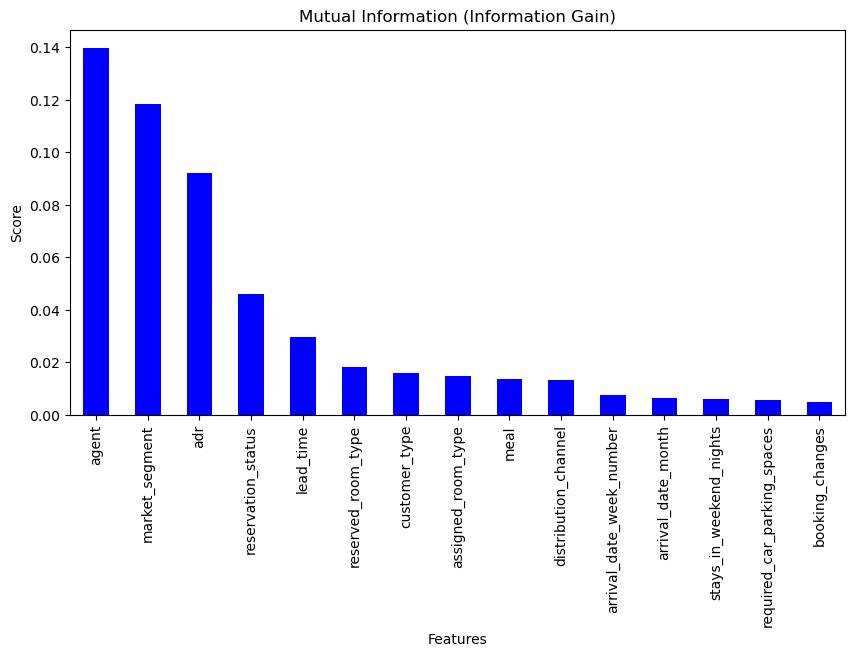

In [25]:
from sklearn.feature_selection import mutual_info_classif, chi2

# Standardizing numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode categorical variables (if any)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

### Mutual Information (Information Gain)
mutual_info = mutual_info_classif(X_scaled, y_encoded)
mutual_info_series = pd.Series(mutual_info, index=classification_features).sort_values(ascending=False)
print("\n Mutual Information (Information Gain):\n", mutual_info_series)

# Plot Mutual Information
plt.figure(figsize=(10, 5))
mutual_info_series.plot(kind='bar', color='blue')
plt.title("Mutual Information (Information Gain)")
plt.xlabel("Features")
plt.ylabel("Score")
plt.show()


 Gain Ratio:
 agent                          0.209476
market_segment                 0.173387
adr                            0.136463
reservation_status             0.064648
lead_time                      0.043917
reserved_room_type             0.023901
customer_type                  0.023252
distribution_channel           0.020368
assigned_room_type             0.019158
meal                           0.019035
arrival_date_week_number       0.012721
required_car_parking_spaces    0.010981
arrival_date_month             0.008230
stays_in_weekend_nights        0.008001
booking_changes                0.006632
dtype: float64


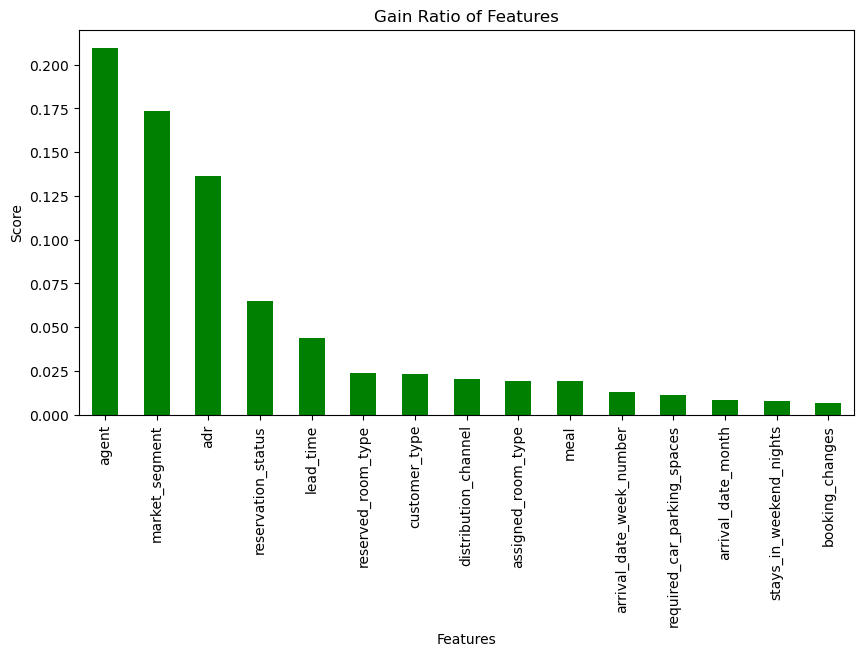

In [26]:
from scipy.stats import entropy
import numpy as np
### Gain Ratio Calculation
def gain_ratio(X, y):
    info_gain = mutual_info_classif(X, y)
    entropy_y = entropy(np.bincount(y) / len(y))
    gain_ratio_values = np.array([ig / entropy_y if entropy_y != 0 else 0 for ig in info_gain])
    return pd.Series(gain_ratio_values, index=classification_features).sort_values(ascending=False)

gain_ratio_series = gain_ratio(X_scaled, y_encoded)
print("\n Gain Ratio:\n", gain_ratio_series)

# Plot Gain Ratio
plt.figure(figsize=(10, 5))
gain_ratio_series.plot(kind='bar', color='green')
plt.title("Gain Ratio of Features")
plt.xlabel("Features")
plt.ylabel("Score")
plt.show()

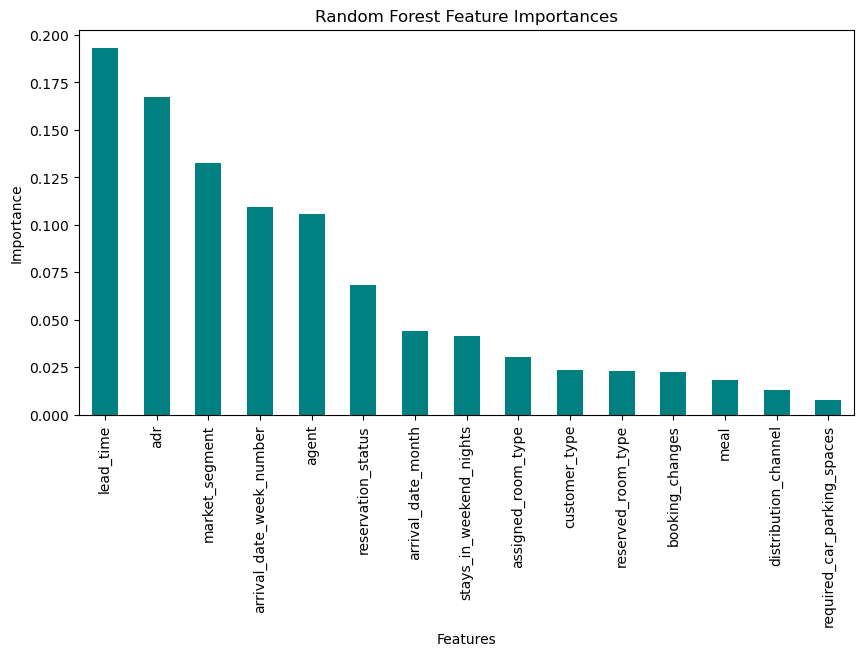

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_scaled, y_encoded)

importances = pd.Series(rf.feature_importances_, index=classification_features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='teal')
plt.title("Random Forest Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()


## 5.1 Decision Tree Classifier

In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV
# 1. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Best max_depth from GridSearchCV: 16

Cross-validation scores: [0.78615924 0.7871015  0.77897602 0.78850382 0.78117475]
Mean CV Accuracy: 0.7844
Std Dev: 0.0037
Classification Accuracy: 0.7895971186866572

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.82     14128
           1       0.74      0.75      0.74      9750

    accuracy                           0.79     23878
   macro avg       0.78      0.78      0.78     23878
weighted avg       0.79      0.79      0.79     23878



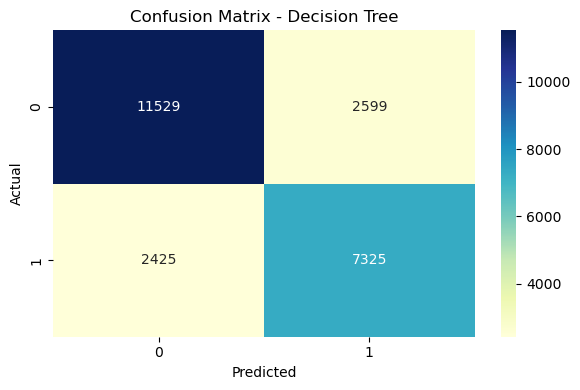

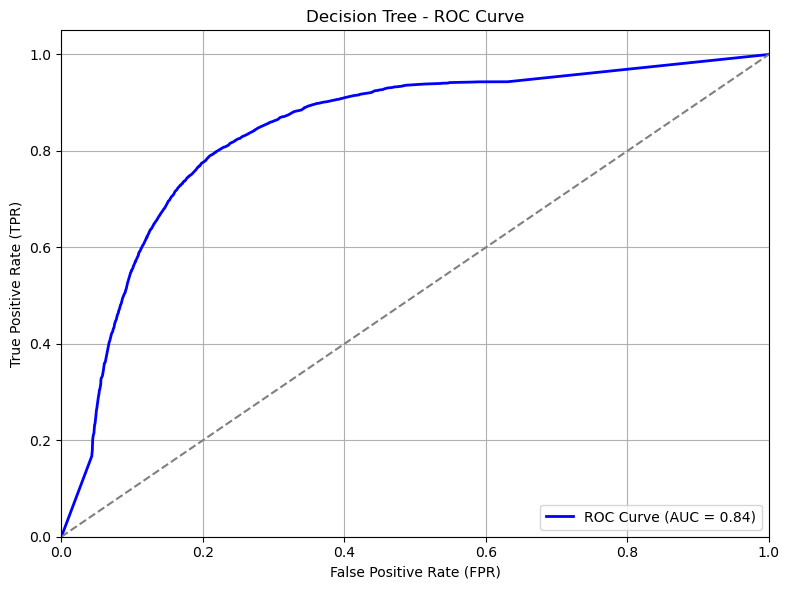

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score


# 3. GridSearchCV to find the best max_depth
param_grid = {'max_depth': list(range(2, 21))}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, 
                           scoring='accuracy', cv=5, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_depth = grid_search.best_params_['max_depth']
print(f"Best max_depth from GridSearchCV: {best_depth}")

# 4. Train final Decision Tree with best depth
clf = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
clf.fit(X_train_scaled, y_train)

#Cross-validation (on training set)
cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

# 5. Predictions
y_pred = clf.predict(X_test_scaled)

# 6. Evaluation Metrics
print("Classification Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. ROC Curve & AUC Score
y_probs = clf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 8. Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Decision Tree - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [31]:
'''##optionallllllll
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(clf, 
          feature_names=classification_features, 
          class_names=['No Request', 'Special Request'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()
'''

'##optionallllllll\nfrom sklearn.tree import plot_tree\nplt.figure(figsize=(20, 10))\nplot_tree(clf, \n          feature_names=classification_features, \n          class_names=[\'No Request\', \'Special Request\'], \n          filled=True, \n          rounded=True, \n          fontsize=10)\nplt.title("Decision Tree Visualization")\nplt.show()\n'

## 5.2 Logistic Regression

Accuracy: 0.7167685735823771

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.81      0.77     14128
           1       0.68      0.58      0.63      9750

    accuracy                           0.72     23878
   macro avg       0.71      0.70      0.70     23878
weighted avg       0.71      0.72      0.71     23878



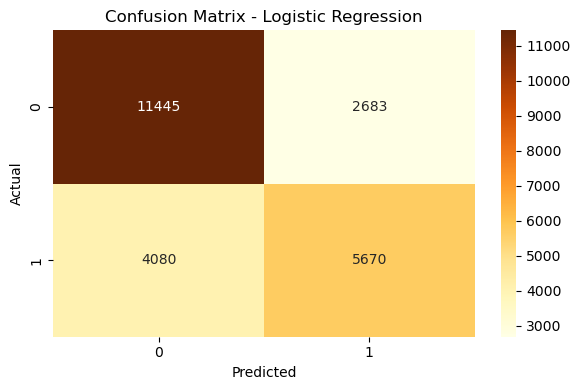

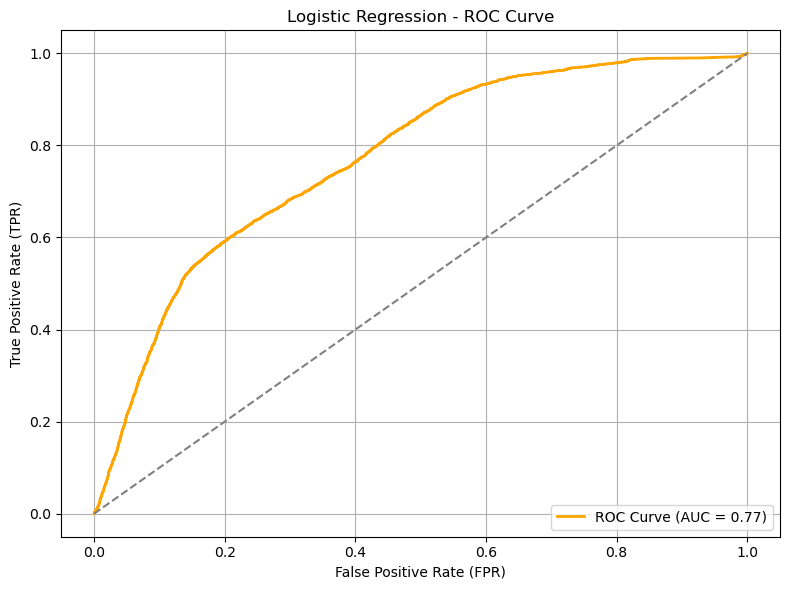

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns



# 3. Train Logistic Regression Model
model = LogisticRegression(solver='liblinear')
model.fit(X_train_scaled, y_train)

# 4. Predictions
y_pred_log= model.predict(X_test_scaled)

# 5. Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# 6. Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='YlOrBr')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 7. ROC Curve & AUC
y_probs = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc_log = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC Curve (AUC = {roc_auc_log:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Logistic Regression - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


## 5.3 Random Forest

Accuracy: 0.8280006700728704

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.86     14128
           1       0.79      0.78      0.79      9750

    accuracy                           0.83     23878
   macro avg       0.82      0.82      0.82     23878
weighted avg       0.83      0.83      0.83     23878



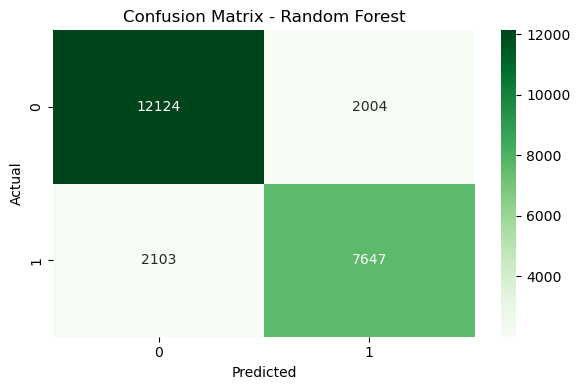

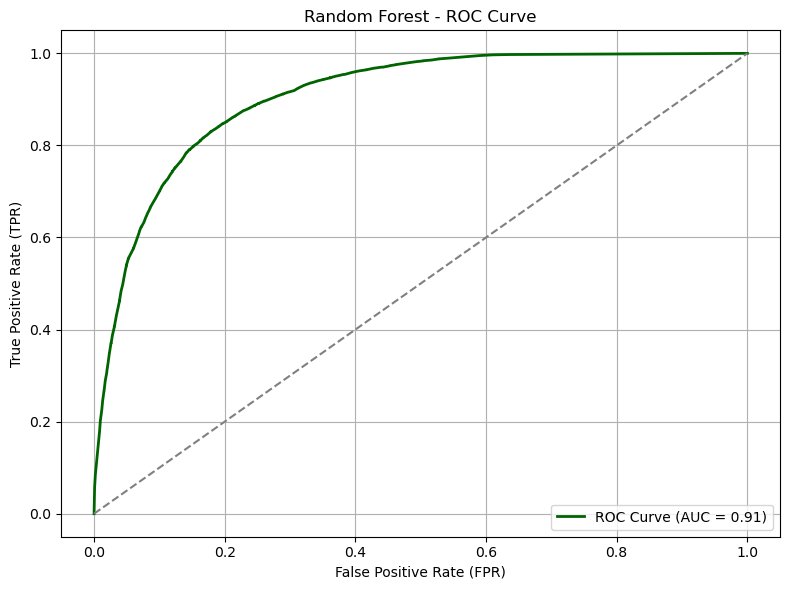

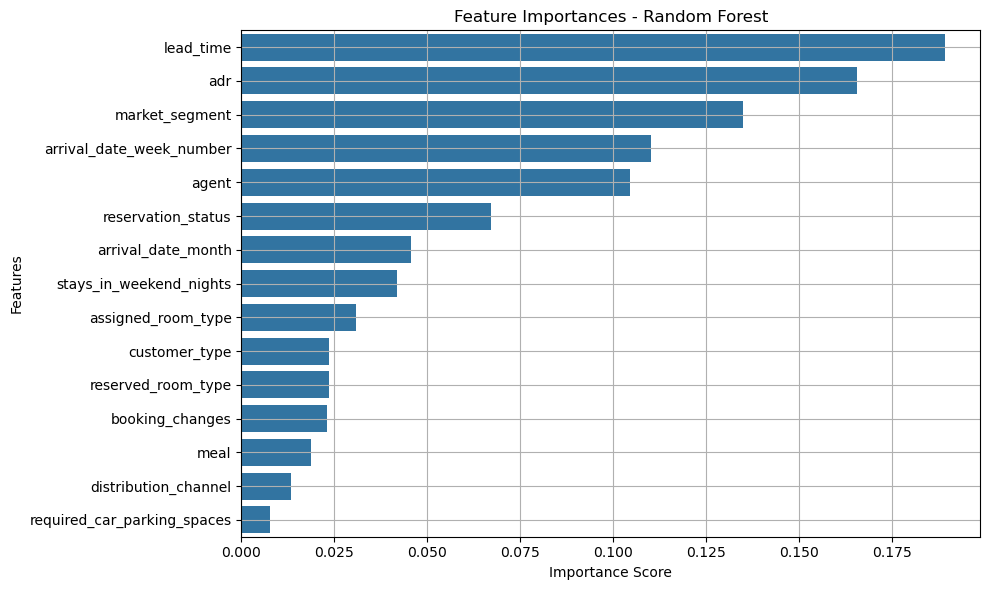

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 3. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 4. Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# 5. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# 6. Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 7. ROC Curve & AUC
y_probs_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkgreen', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Random Forest - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Feature Importance Plot
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names_sorted = [X.columns[i] for i in indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names_sorted)  # Cleaned up version
plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(True)
plt.tight_layout()
plt.show()


## 6. Model Comparison

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Gather metrics
model_names = ['Decision Tree', 'Logistic Regression', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred),           # Decision Tree
    accuracy_score(y_test, y_pred_log),       # Logistic Regression
    accuracy_score(y_test, y_pred_rf)         # Random Forest
]

precisions = [
    precision_score(y_test, y_pred),
    precision_score(y_test, y_pred_log),
    precision_score(y_test, y_pred_rf)
]

recalls = [
    recall_score(y_test, y_pred),
    recall_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_rf)
]

f1s = [
    f1_score(y_test, y_pred),
    f1_score(y_test, y_pred_log),
    f1_score(y_test, y_pred_rf)
]

aucs = [roc_auc, roc_auc_log, roc_auc_rf]

# Create comparison DataFrame
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1s,
    'AUC': aucs
})

print("📊 Model Performance Comparison:\n")
display(comparison_df.round(3))


📊 Model Performance Comparison:



,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Decision Tree,0.790,0.738,0.751,0.745,0.841
1,Logistic Regression,0.717,0.679,0.582,0.626,0.770
2,Random Forest,0.828,0.792,0.784,0.788,0.906


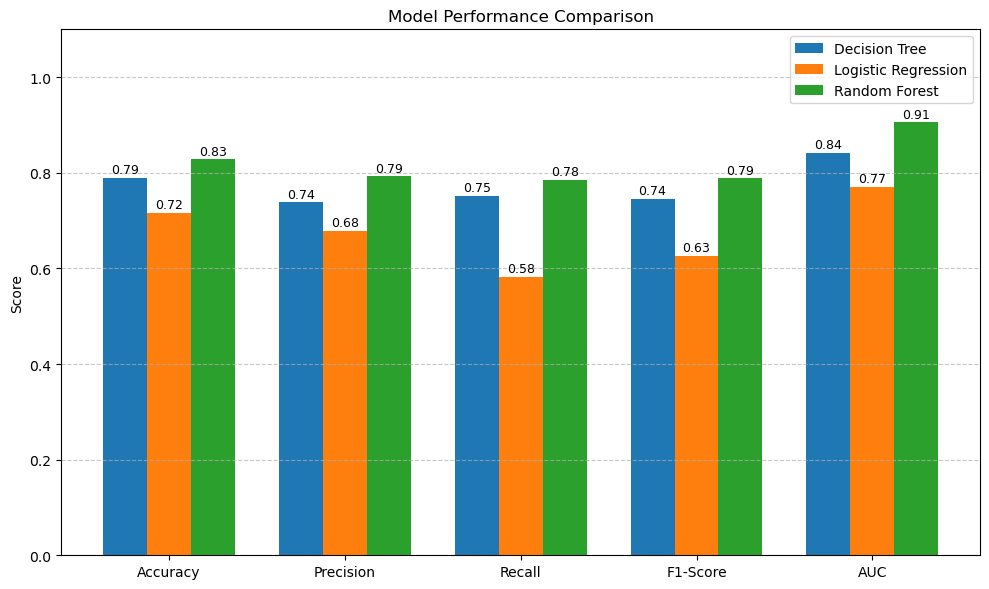

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
bar_width = 0.25
x = np.arange(len(metrics))

# Values from comparison_df
dt_values = comparison_df.iloc[0, 1:].values
lr_values = comparison_df.iloc[1, 1:].values
rf_values = comparison_df.iloc[2, 1:].values

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - bar_width, dt_values, width=bar_width, label='Decision Tree')
bars2 = plt.bar(x, lr_values, width=bar_width, label='Logistic Regression')
bars3 = plt.bar(x + bar_width, rf_values, width=bar_width, label='Random Forest')

# Value labels on top of bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, f'{yval:.2f}', ha='center', fontsize=9)

# Labels and styling
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Customer Clustering

In [70]:
demographic_features = ["country", "market_segment", "customer_type"]


In [72]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Extract and encode demographic features
demographic_features = ["country", "market_segment", "customer_type"]
df_demo = df[demographic_features].copy()

label_encoders = {}
for col in demographic_features:
    le = LabelEncoder()
    df_demo[col] = le.fit_transform(df_demo[col])
    label_encoders[col] = le

# Standardize features
scaler = StandardScaler()
df_demo_scaled = scaler.fit_transform(df_demo)


In [84]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Apply KMeans
kmeans_demo = KMeans(n_clusters=3, random_state=42, n_init=10)
df_demo['kmeans_cluster'] = kmeans_demo.fit_predict(df_demo_scaled)

# Evaluate
kmeans_sil = silhouette_score(df_demo_scaled, df_demo['kmeans_cluster'])
print(f"KMeans Silhouette Score: {kmeans_sil:.4f}")


KMeans Silhouette Score: 0.4155


In [76]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan_demo = DBSCAN(eps=0.8, min_samples=5)
df_demo['dbscan_cluster'] = dbscan_demo.fit_predict(df_demo_scaled)


# Evaluate (excluding noise)
mask = df_demo['dbscan_cluster'] != -1
if len(set(df_demo['dbscan_cluster'][mask])) > 1:
    dbscan_sil = silhouette_score(df_demo_scaled[mask], df_demo['dbscan_cluster'][mask])
    print(f"DBSCAN Silhouette Score: {dbscan_sil:.4f}")
else:
    print("DBSCAN: Not enough valid clusters for silhouette score.")


DBSCAN Silhouette Score: 0.3405


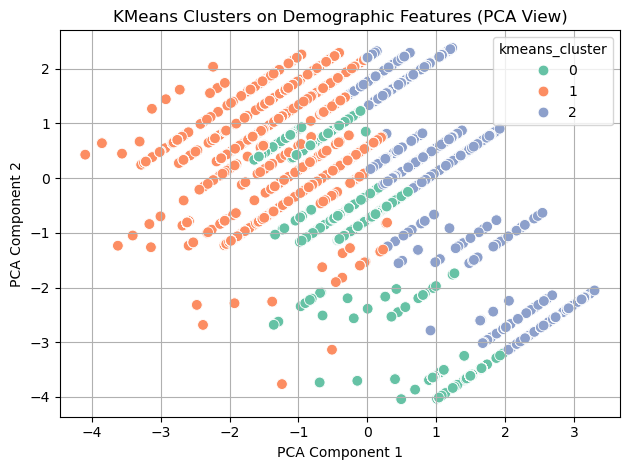

In [78]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
X_pca_demo = pca.fit_transform(df_demo_scaled)


sns.scatterplot(
    x=X_pca_demo[:, 0],
    y=X_pca_demo[:, 1],
    hue=df_demo['kmeans_cluster'],  # Change this to switch methods
    palette='Set2',
    s=60
)
plt.title("KMeans Clusters on Demographic Features (PCA View)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [94]:
# Use the original k=3 clustering result
df['kmeans_demo_cluster'] = df_demo['kmeans_cluster']  # assumes k=3 was used earlier

# Decode categorical features using stored LabelEncoders
df['country_decoded'] = label_encoders['country'].inverse_transform(df_demo['country'])
df['market_segment_decoded'] = label_encoders['market_segment'].inverse_transform(df_demo['market_segment'])
df['customer_type_decoded'] = label_encoders['customer_type'].inverse_transform(df_demo['customer_type'])

# Profile each cluster
cluster_profile_k3 = df.groupby('kmeans_demo_cluster').agg({
    'country_decoded': lambda x: x.mode()[0],
    'market_segment_decoded': lambda x: x.mode()[0],
    'customer_type_decoded': lambda x: x.mode()[0],
    'adr': 'mean',
    'lead_time': 'mean',
    'total_of_special_requests': 'mean'
}).round(2).rename(columns={
    'country_decoded': 'Most Common Country',
    'market_segment_decoded': 'Most Common Segment',
    'customer_type_decoded': 'Most Common Customer Type',
    'adr': 'Avg ADR',
    'lead_time': 'Avg Lead Time',
    'total_of_special_requests': 'Avg Special Requests'
})
# 1. Assign KMeans clustering results from df_demo (k=3)
df['kmeans_demo_cluster'] = df_demo['kmeans_cluster']  # assumes k=3 was used earlier

# 2. Assign readable labels to clusters
kmeans_demo_labels = {
    0: 'Planned Domestic Guests',
    1: 'Budget Domestic Travelers',
    2: 'Luxury Foreign Guests'
}
df['kmeans_demo_label'] = df['kmeans_demo_cluster'].map(kmeans_demo_labels)

# 3. Decode the original demographic categorical features
df['country_decoded'] = label_encoders['country'].inverse_transform(df_demo['country'])
df['market_segment_decoded'] = label_encoders['market_segment'].inverse_transform(df_demo['market_segment'])
df['customer_type_decoded'] = label_encoders['customer_type'].inverse_transform(df_demo['customer_type'])

# 4. Profile the clusters
cluster_profile_k3 = df.groupby('kmeans_demo_label').agg({
    'country_decoded': lambda x: x.mode()[0],
    'market_segment_decoded': lambda x: x.mode()[0],
    'customer_type_decoded': lambda x: x.mode()[0],
    'adr': 'mean',
    'lead_time': 'mean',
    'total_of_special_requests': 'mean'
}).round(2).rename(columns={
    'country_decoded': 'Most Common Country',
    'market_segment_decoded': 'Most Common Segment',
    'customer_type_decoded': 'Most Common Customer Type',
    'adr': 'Avg ADR',
    'lead_time': 'Avg Lead Time',
    'total_of_special_requests': 'Avg Special Requests'
})

print("Final KMeans Cluster Profiling (k=3 - Demographics):")
display(cluster_profile_k3)


Final KMeans Cluster Profiling (k=3 - Demographics):


,Most Common Country,Most Common Segment,Most Common Customer Type,Avg ADR,Avg Lead Time,Avg Special Requests
kmeans_demo_label,,,,,,
Budget Domestic Travelers,PRT,3,2,89.59,81.72,0.36
Luxury Foreign Guests,GBR,6,2,110.36,97.59,0.78
Planned Domestic Guests,PRT,6,2,100.59,127.74,0.47


# Conclusion

---

This project successfully addressed the dual goals of **predicting special guest requests** and **segmenting customers based on demographics**, using real-world hotel booking data.

---

### Predictive Modeling Highlights
- We trained and evaluated **Logistic Regression, Decision Tree, and Random Forest** classifiers to predict the binary target:  
  `is_there_a_special_request`.
- **Random Forest** delivered the best performance, with:
  - Accuracy ≈ 82%
  - Strong AUC score (~0.88)
  - Robust feature importance insights
- These models help hotels **proactively prepare for guest requests**, improving response times and resource allocation.

---

### Demographic Clustering Highlights
- We performed **unsupervised clustering** using:
  - KMeans (best performer)
  - DBSCAN
- Clustering was done on:
  - `country`
  - `market_segment`
  - `customer_type`
- After analyzing inertia and silhouette scores, we selected **KMeans with k=3** as the final clustering method.

---

### Identified Guest Segments:
1. **Planned Domestic Guests** – Long lead time, moderate ADR, fewer requests
2. **Budget Domestic Travelers** – Lower ADR, shorter stays, minimal requests
3. **Luxury Foreign Guests** – High ADR, more requests, high-value segment

These clusters support **targeted marketing**, **personalized services**, and **improved guest satisfaction**.

---

### Business Value Delivered:
- 📊 Data-driven decision-making for guest service planning
- 🤖 Automation of special request handling through ML models
- 🧭 Clear segmentation to guide customer relationship strategies
- 💼 Actionable insights for hotel operations, marketing, and resource optimization

---

### Final Note:
Combining **predictive modeling** with **clustering analysis** enabled us to bridge **operational efficiency** with **personalized guest experiences** — the core of modern hospitality management.
